# Vežbe 8: Konvolucione neuronske mreže u PyTorch-u

U ovom notebook-u prikazana je izgradnja jednostavne konvolucione neuronske mreže za klasifikaciju slika iz CIFAR-10 skupa podataka.

In [1]:
# Import potrebnih biblioteka

import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

## 1. Učitavanje skupa podataka

In [2]:
# Definisati transformacije koje se primenjuju nad slikama

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

In [3]:
# Učitati trening i test skup CIFAR-10 podataka

train_dataset = datasets.CIFAR10(
    root='data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:02<00:00, 69.2MB/s]


In [4]:
# Prikazati broj slika u trening i test skupu

print("Broj slika u trening skupu:", len(train_dataset))
print("Broj slika u test skupu:", len(test_dataset))

Broj slika u trening skupu: 50000
Broj slika u test skupu: 10000


## 2. Kreiranje batch-eva pomoću DataLoader-a

In [5]:
# Formirati DataLoader objekte za trening i test skup
# Koristiti batch_size = 4

batch_size = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [6]:
# Definisati nazive klasa iz CIFAR-10 skupa podataka ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

classes = (
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)

## 4. Prikaz nekoliko slika iz trening skupa

In [7]:
# Definisati funkciju za prikaz slika

def imshow(img):
    img = img / 2 + 0.5  # denormalizacija
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

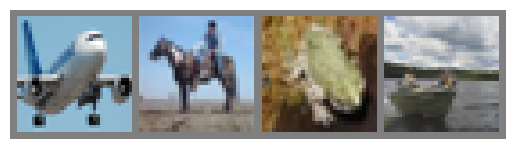

Klase: plane horse frog  ship 


In [8]:
# Učitati jedan batch slika iz trening skupa i prikazati ga

dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))

print('Klase:', ' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

## 5. Definisanje konvolucione neuronske mreže


In [9]:
# Definisati klasu konvolucione neuronske mreže

class ConvolutionalNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1)

        self.fc1 = nn.Linear(16 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))

        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        x = self.fc3(x)

        return x

In [10]:
# Definisati novu klasu konvolucione neuronske mreže (dodati padding 2)

class ConvolutionalNN2(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=2)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=2)

        self.fc1 = nn.Linear(16 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))

        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        x = self.fc3(x)

        return x

In [11]:
# Kreirati instancu prethodno definisanog modela

net = ConvolutionalNN()
net

ConvolutionalNN(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

## 6. Definisanje funkcije greške i optimizacionog algoritma


In [12]:
# Definisati funkciju greške CrossEntropy i SGD optimizacioni algoritam (lr=0.001, momentum=0.9)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    net.parameters(),
    lr=0.001,
    momentum=0.9
)

## 7. Trening modela

In [13]:
# Istrenirati model

net.train()

for epoch in range(5):

    train_loss = 0.0

    for inputs, labels in train_loader:

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoha {epoch+1}, loss: {train_loss / len(train_loader):.3f}")

Epoha 1, loss: 1.721
Epoha 2, loss: 1.339
Epoha 3, loss: 1.192
Epoha 4, loss: 1.098
Epoha 5, loss: 1.029


## 8. Čuvanje treniranog modela

In [14]:
# Sačuvati parametre treniranog modela

PATH = './cifar_net.pth'

torch.save(net.state_dict(), PATH)

## 9. Prikaz nekoliko slika iz test skupa

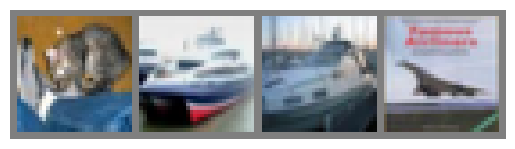

Stvarne klase: cat   ship  ship  plane


In [15]:
# Učitati jedan batch slika iz test skupa

dataiter = iter(test_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))

print('Stvarne klase:', ' '.join(
    f'{classes[labels[j].item()]:5s}' for j in range(len(labels))
))

## 10. Testiranje modela na nekoliko slika


In [16]:
# Ponovo kreirati model i učitati sačuvane parametre

net = ConvolutionalNN()
net.load_state_dict(torch.load(PATH))

<All keys matched successfully>

In [17]:
# Izračunati predikcije modela za prikazane test slike

outputs = net(images)

_, predicted = torch.max(outputs, 1)

print('Predikcije:', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(batch_size)))

Predikcije: cat   ship  ship  ship 


## 11. Predikcije modela


In [18]:
# Izračunati predikcije modela nad test skupom i sačuvati stvarne i predviđene klase

net.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        outputs = net(images)

        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Broj predikcija:", len(all_preds))

Broj predikcija: 10000


## 12. Matrica konfuzije

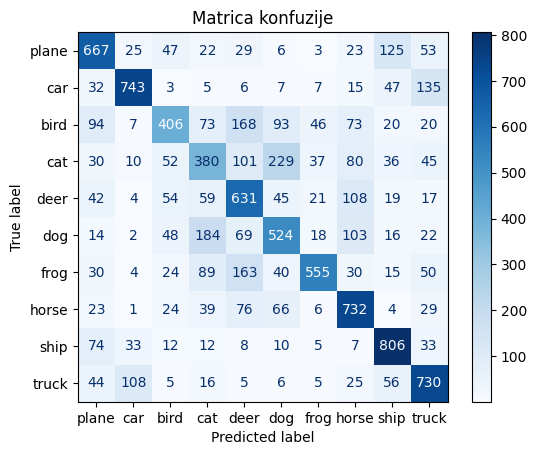

In [19]:
# Izračunati i prikazati matricu konfuzije

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues")
plt.title("Matrica konfuzije")
plt.show()

## 12. Evaluacija modela

In [20]:
# Izračunati tačnost po klasama

correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

for label, prediction in zip(all_labels, all_preds):

    if label == prediction:
        correct_pred[classes[label]] += 1

    total_pred[classes[label]] += 1

# Ispisati tačnost po klasama.

for classname in classes:
    accuracy = 100 * correct_pred[classname] / total_pred[classname]
    print(f'Tačnost za klasu {classname:5s}: {accuracy:.1f} %')

Tačnost za klasu plane: 66.7 %
Tačnost za klasu car  : 74.3 %
Tačnost za klasu bird : 40.6 %
Tačnost za klasu cat  : 38.0 %
Tačnost za klasu deer : 63.1 %
Tačnost za klasu dog  : 52.4 %
Tačnost za klasu frog : 55.5 %
Tačnost za klasu horse: 73.2 %
Tačnost za klasu ship : 80.6 %
Tačnost za klasu truck: 73.0 %


In [21]:
# Izračunati accuracy i classification report

accuracy = accuracy_score(all_labels, all_preds)
print("Tačnost modela:", round(accuracy, 4))

print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=classes))

Tačnost modela: 0.6174

Classification report:
              precision    recall  f1-score   support

       plane       0.64      0.67      0.65      1000
         car       0.79      0.74      0.77      1000
        bird       0.60      0.41      0.48      1000
         cat       0.43      0.38      0.40      1000
        deer       0.50      0.63      0.56      1000
         dog       0.51      0.52      0.52      1000
        frog       0.79      0.56      0.65      1000
       horse       0.61      0.73      0.67      1000
        ship       0.70      0.81      0.75      1000
       truck       0.64      0.73      0.68      1000

    accuracy                           0.62     10000
   macro avg       0.62      0.62      0.61     10000
weighted avg       0.62      0.62      0.61     10000

